In [1]:
!pip -q install -U \
  "transformers==4.57.3" \
  "trl==0.26.2" \
  "peft==0.18.0" \
  "bitsandbytes==0.49.0" \
  "kernels==0.11.5" \
  accelerate datasets evaluate scikit-learn pandas matplotlib tensorboard tqdm tiktoken

# Optional (extra speed). If it fails on your env, just rerun without it.
!pip -q install -U liger-kernel


In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:256"

In [ ]:
import gc, torch

try:
    del trainer
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()

In [ ]:
import os
import re
import json
import ast
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    set_seed,
)

from peft import LoraConfig, TaskType, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer

# ---------- Repro ----------
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---------- Speed ----------
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# ---------- GPU ----------
assert torch.cuda.is_available(), "CUDA is not available. Please enable a GPU runtime."
gpu_name = torch.cuda.get_device_name(0)
gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
print(f"GPU: {gpu_name} | VRAM: {gpu_mem_gb:.1f} GB")


GPU: NVIDIA A100-SXM4-40GB | VRAM: 39.5 GB


In [4]:
raw_ds = load_dataset("vohuutridung/3190-data")
raw_ds

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 300
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 597
    })
})

In [5]:
print("Train:", len(raw_ds["train"]))
print("Val  :", len(raw_ds["validation"]))
print("Test :", len(raw_ds["test"]))

print("\nExample:")
ex0 = raw_ds["train"][0]
print("TEXT:", ex0["text"])
print("LABELS:", ex0["labels"])

Train: 10000
Val  : 300
Test : 597

Example:
TEXT: Mới mua cách đây gần một tháng. Mọi thứ đều rất tốt nhưng pin em xài mới đây đã bị chai 1 phần trăm rồi :(((
LABELS: [['Mọi thứ', 'TỔNG_QUAN', 'TÍCH_CỰC', 'đều rất tốt'], ['pin', 'PIN', 'TIÊU_CỰC', 'bị chai 1 phần trăm rồi']]


In [6]:
def extract_label_vocabs(ds_split, max_rows=None):
    cats, sents = set(), set()
    n = len(ds_split) if max_rows is None else min(len(ds_split), max_rows)
    for i in range(n):
        for quad in ds_split[i]["labels"]:
            if len(quad) >= 3:
                cats.add(str(quad[1]))
                sents.add(str(quad[2]))
    return sorted(cats), sorted(sents)

cats, sents = extract_label_vocabs(raw_ds["train"])
print("Aspect categories:", cats)
print("Sentiments:", sents)

Aspect categories: ['CAMERA', 'DỊCH_VỤ', 'DỊCH_VỤ&PHỤ_KIỆN', 'GIÁ_CẢ', 'HIỆU_NĂNG', 'LOA', 'LOA_THOẠI', 'LƯU TRỮ', 'MÀN_HÌNH', 'MÁY_ẢNH', 'PIN', 'THIẾT_KẾ', 'TÍNH_NĂNG', 'TỔNG_QUAN', 'VÂN_TAY']
Sentiments: ['TIÊU_CỰC', 'TRUNG_LẬP', 'TÍCH_CỰC']


In [7]:
SYSTEM_PROMPT = (
    "Bạn là hệ thống trích xuất khía cạnh và cảm xúc (Aspect-Based Sentiment Analysis) cho review sản phẩm.\n"
    "Nhiệm vụ: từ một đoạn review tiếng Việt, trích xuất các mục theo định dạng JSON:\n"
    '[[ "aspect_term", "aspect_category", "sentiment", "opinion_phrase" ], ...]\n'
    "Quy tắc:\n"
    "- Chỉ trả về JSON thuần (không giải thích, không markdown).\n"
    "- Giữ nguyên nhãn như dữ liệu (ví dụ: TỔNG_QUAN, PIN, ...; TÍCH_CỰC/TIÊU_CỰC/TRUNG_LẬP).\n"
    '- Nếu thiếu aspect_term hoặc opinion_phrase, dùng chuỗi "NULL" đúng như dữ liệu.\n'
)

USER_TEMPLATE = (
    "Hãy trích xuất các khía cạnh và cảm xúc từ review sau.\n"
    "Review:\n"
    "{text}\n\n"
    "Chỉ trả về JSON theo đúng format yêu cầu."
)

def to_prompt_completion(example):
    text = (example["text"] or "").strip()
    # Make sure completion is valid JSON, keep Vietnamese characters
    completion_json = json.dumps(example["labels"], ensure_ascii=False)
    return {
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": USER_TEMPLATE.format(text=text)},
        ],
        "completion": [
            {"role": "assistant", "content": completion_json}
        ],
    }

def add_length(ex):
    # crude but effective: approximate length using rendered prompt+completion
    # (exact length isn't required; just needs to correlate with true length)
    msgs = ex["prompt"] + ex["completion"]
    text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
    ex["length"] = len(tokenizer(text, add_special_tokens=False).input_ids)
    return ex

train_pc = raw_ds["train"].map(to_prompt_completion, remove_columns=raw_ds["train"].column_names)
val_pc   = raw_ds["validation"].map(to_prompt_completion, remove_columns=raw_ds["validation"].column_names)

print(train_pc[0])

{'prompt': [{'content': 'Bạn là hệ thống trích xuất khía cạnh và cảm xúc (Aspect-Based Sentiment Analysis) cho review sản phẩm.\nNhiệm vụ: từ một đoạn review tiếng Việt, trích xuất các mục theo định dạng JSON:\n[[ "aspect_term", "aspect_category", "sentiment", "opinion_phrase" ], ...]\nQuy tắc:\n- Chỉ trả về JSON thuần (không giải thích, không markdown).\n- Giữ nguyên nhãn như dữ liệu (ví dụ: TỔNG_QUAN, PIN, ...; TÍCH_CỰC/TIÊU_CỰC/TRUNG_LẬP).\n- Nếu thiếu aspect_term hoặc opinion_phrase, dùng chuỗi "NULL" đúng như dữ liệu.\n', 'role': 'system'}, {'content': 'Hãy trích xuất các khía cạnh và cảm xúc từ review sau.\nReview:\nMới mua cách đây gần một tháng. Mọi thứ đều rất tốt nhưng pin em xài mới đây đã bị chai 1 phần trăm rồi :(((\n\nChỉ trả về JSON theo đúng format yêu cầu.', 'role': 'user'}], 'completion': [{'content': '[["Mọi thứ", "TỔNG_QUAN", "TÍCH_CỰC", "đều rất tốt"], ["pin", "PIN", "TIÊU_CỰC", "bị chai 1 phần trăm rồi"]]', 'role': 'assistant'}]}


In [8]:
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)

# Ensure pad token exists
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# QLoRA (4-bit NF4)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model_load_kwargs = dict(
    device_map="auto",
    torch_dtype=torch.bfloat16,
    quantization_config=bnb_config,
    low_cpu_mem_usage=True,
)

# Try kernels-community FlashAttention first (fast + enables packing)
USE_FLASH_KERNEL = False
try:
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        attn_implementation="kernels-community/flash-attn2",
        **model_load_kwargs,
    )
    USE_FLASH_KERNEL = True
    print("✅ Using kernels-community/flash-attn2 attention backend.")
except Exception as e:
    print("⚠️ Could not use kernels-community/flash-attn2. Falling back to SDPA.")
    print("   Error:", repr(e))
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        attn_implementation="sdpa",
        **model_load_kwargs,
    )

# Training setup
model.config.use_cache = False  # important for training + checkpointing

# Prepare for k-bit training (QLoRA)
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

# Strong LoRA config (high-capacity)
peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=64,
    lora_alpha=128,
    lora_dropout=0.05,
    bias="none",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

print("Flash kernel enabled:", USE_FLASH_KERNEL)

`torch_dtype` is deprecated! Use `dtype` instead!


Fetching 20 files:   0%|          | 0/20 [00:00<?, ?it/s]

Fetching 20 files:   0%|          | 0/20 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Using kernels-community/flash-attn2 attention backend.
Flash kernel enabled: True


In [9]:
OUTPUT_DIR = Path("qwen2.5-3b-absa-qlora")
LOG_DIR = OUTPUT_DIR / "tb_logs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

# Batch size heuristic for A100 variants (keeps effective batch ~32)
if gpu_mem_gb >= 70:
    per_device_bs = 32
    grad_accum = 1
elif gpu_mem_gb >= 35:
    per_device_bs = 16
    grad_accum = 2
else:
    per_device_bs = 8
    grad_accum = 4

print(f"per_device_train_batch_size={per_device_bs}, gradient_accumulation_steps={grad_accum}")

from pathlib import Path

OUTPUT_DIR = Path("./qwen25_3b_asa_lora")
LOG_DIR    = OUTPUT_DIR / "logs"

SAVE_EVAL_STEPS = 50  # must match for load_best_model_at_end

training_args = SFTConfig(
    output_dir=str(OUTPUT_DIR),
    logging_dir=str(LOG_DIR),
    report_to=["tensorboard"],

    # training
    num_train_epochs=6,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    max_grad_norm=1.0,

    per_device_train_batch_size=16,
    gradient_accumulation_steps=2,

    # eval + save (IMPORTANT: must be aligned when load_best_model_at_end=True)
    eval_strategy="steps",
    eval_steps=SAVE_EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_EVAL_STEPS,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=3,

    # memory safety for eval
    per_device_eval_batch_size=1,
    prediction_loss_only=True,     # don't store logits during eval
    eval_accumulation_steps=1,
    torch_empty_cache_steps=SAVE_EVAL_STEPS,

    # speed / stability
    bf16=True,
    tf32=True,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    optim="adamw_torch_fused",

    # seq config
    max_length=2048,
    packing=True,
    completion_only_loss=True,

    # ✅ IMPORTANT: avoid Liger here to prevent “logits missing / token_accuracy None” paths
    # (Liger may omit logits; see reports about missing logits) 
    use_liger_kernel=False,
)

print("OK: training_args created")
print("save_steps =", training_args.save_steps, "eval_steps =", training_args.eval_steps)
# Optional: try Liger kernels if installed (extra speed); safe to ignore if not available.
try:
    import liger_kernel  # noqa: F401
    training_args.use_liger_kernel = True
    print("✅ Liger kernel detected: enabling use_liger_kernel=True")
except Exception:
    print("ℹ️ Liger kernel not available: training without it.")

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_pc,
    eval_dataset=val_pc,
    peft_config=peft_config,
    processing_class=tokenizer,
)

per_device_train_batch_size=16, gradient_accumulation_steps=2
OK: training_args created
save_steps = 50 eval_steps = 50
✅ Liger kernel detected: enabling use_liger_kernel=True


In [10]:
from trl import SFTTrainer

class SFTTrainerNoExtraMetrics(SFTTrainer):
    """
    Removes the extra metric computations (entropy / mean_token_accuracy) that can crash
    when token-accuracy/logits are None.
    Keeps normal loss training + eval_loss logging + checkpointing.
    """
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model(**inputs)
        loss = outputs.loss  # works for causal LM when labels are provided by the collator
        return (loss, outputs) if return_outputs else loss

In [11]:
# IMPORTANT: use_cache must be False with gradient checkpointing
model.config.use_cache = False
train_dataset = train_pc
eval_dataset  = val_pc

trainer = SFTTrainerNoExtraMetrics(
    model=model,
    args=training_args,
    train_dataset=train_dataset,   # <-- your processed prompt/completion train split
    eval_dataset=eval_dataset,     # <-- your processed prompt/completion val split
    peft_config=peft_config,       # <-- your LoRA config
    processing_class=tokenizer,
    #data_collator=data_collator,   # <-- your collator
)

print("Trainer rebuilt OK.")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:282: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Trainer rebuilt OK.


In [12]:
from pathlib import Path

def get_latest_checkpoint(output_dir: Path):
    ckpts = sorted(output_dir.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[-1]))
    return str(ckpts[-1]) if ckpts else None

resume = get_latest_checkpoint(OUTPUT_DIR)
print("Resuming from:", resume)

train_result = trainer.train(resume_from_checkpoint=resume)
trainer.save_model(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))

print("Training done.")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Resuming from: qwen25_3b_asa_lora/checkpoint-200


Casting fp32 inputs back to torch.bfloat16 for flash-attn compatibility.


Step,Training Loss,Validation Loss
250,0.059800,0.129028
300,0.038000,0.144882


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Training done.


In [15]:
# trainer.model.config.use_cache = False

# import glob
# import os

# ckpts = sorted(glob.glob(os.path.join(str(OUTPUT_DIR), "checkpoint-*")),
#                key=lambda x: int(x.split("-")[-1]) if x.split("-")[-1].isdigit() else -1)
# print("Found checkpoints:", ckpts[-3:])

# resume = ckpts[-1] if len(ckpts) else None
# print("Resuming from:", resume)

# train_result = trainer.train(resume_from_checkpoint=resume)


# # Save final adapter + tokenizer
# trainer.save_model(str(OUTPUT_DIR))
# tokenizer.save_pretrained(str(OUTPUT_DIR))

# # Save trainer logs for plotting later
# log_history = trainer.state.log_history

# with open(OUTPUT_DIR / "log_history.json", "w", encoding="utf-8") as f:
#     json.dump(log_history, f, ensure_ascii=False, indent=2)

# df_logs = pd.DataFrame(log_history)
# df_logs.to_csv(OUTPUT_DIR / "log_history.csv", index=False)

# print("Saved:")
# print("-", OUTPUT_DIR / "log_history.json")
# print("-", OUTPUT_DIR / "log_history.csv")
# print("-", LOG_DIR, "(TensorBoard events)")
# df_logs.tail(10)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Found checkpoints: []
Resuming from: None


Step,Training Loss,Validation Loss


AttributeError: 'NoneType' object has no attribute 'mean'

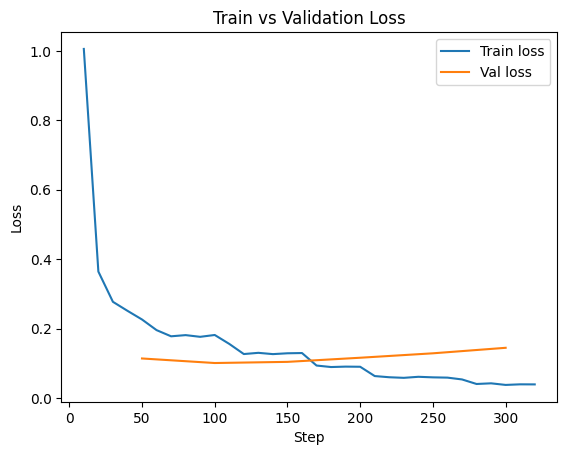

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

df_logs = pd.read_csv(OUTPUT_DIR / "log_history.csv")

train_rows = df_logs[df_logs["loss"].notna() & df_logs["eval_loss"].isna()].copy()
eval_rows  = df_logs[df_logs["eval_loss"].notna()].copy()

plt.figure()
plt.plot(train_rows["step"], train_rows["loss"], color="tab:blue", label="Train loss")
plt.plot(eval_rows["step"],  eval_rows["eval_loss"], color="tab:orange", label="Val loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.show()

In [17]:
def _norm_text(x):
    x = "" if x is None else str(x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def _norm_label(x):
    return _norm_text(x).upper()

def parse_model_json(raw_text):
    """
    Extract the first JSON list found in model output.
    Returns a list (possibly empty). If parsing fails, returns [].
    """
    if raw_text is None:
        return []
    s = str(raw_text).strip()

    # Find JSON array boundaries
    start = s.find("[")
    end = s.rfind("]")
    if start == -1 or end == -1 or end < start:
        return []

    candidate = s[start : end + 1].strip()

    # Try strict JSON
    try:
        obj = json.loads(candidate)
        return obj if isinstance(obj, list) else []
    except Exception:
        pass

    # Try python literal fallback
    try:
        obj = ast.literal_eval(candidate)
        return obj if isinstance(obj, list) else []
    except Exception:
        return []

def to_sets(quads):
    """
    Convert list-of-lists -> normalized sets:
    - ac_set: (aspect_term, category)
    - tri_set: (aspect_term, category, sentiment)
    - quad_set: (aspect_term, category, sentiment, opinion_phrase)
    """
    ac_set, tri_set, quad_set = set(), set(), set()
    if not isinstance(quads, list):
        return ac_set, tri_set, quad_set

    for q in quads:
        if not isinstance(q, (list, tuple)) or len(q) < 4:
            continue
        a, c, s, o = q[0], q[1], q[2], q[3]
        a_n = _norm_text(a)
        c_n = _norm_label(c)
        s_n = _norm_label(s)
        o_n = _norm_text(o)

        ac_set.add((a_n, c_n))
        tri_set.add((a_n, c_n, s_n))
        quad_set.add((a_n, c_n, s_n, o_n))
    return ac_set, tri_set, quad_set

def prf(overlap, pred_total, ref_total):
    p = overlap / pred_total if pred_total > 0 else 0.0
    r = overlap / ref_total if ref_total > 0 else 0.0
    f1 = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0
    return p, r, f1

@torch.inference_mode()
def generate_absa_batch(text_list, max_new_tokens=256):
    model = trainer.model
    model.eval()

    # Build chat prompts
    prompts = []
    for t in text_list:
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": USER_TEMPLATE.format(text=(t or "").strip())},
        ]
        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
        prompts.append(prompt)

    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=training_args.max_length,
    ).to(model.device)

    input_lens = inputs["attention_mask"].sum(dim=1)

    gen_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        num_beams=1,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    outputs = []
    for i in range(len(prompts)):
        gen_part = gen_ids[i][int(input_lens[i]):]
        out_text = tokenizer.decode(gen_part, skip_special_tokens=True)
        outputs.append(out_text)
    return outputs

# ---- Run evaluation on test split ----
test_raw = raw_ds["test"]
bs = per_device_bs  # reuse
pred_parsed_all = []
ref_all = []

for i in tqdm(range(0, len(test_raw), bs), desc="Generating"):
    batch = test_raw[i : i + bs]
    preds_text = generate_absa_batch(batch["text"], max_new_tokens=256)
    preds_parsed = [parse_model_json(x) for x in preds_text]

    pred_parsed_all.extend(preds_parsed)
    ref_all.extend(batch["labels"])

# ---- Compute metrics ----
ac_overlap = ac_pred_total = ac_ref_total = 0
tri_overlap = tri_pred_total = tri_ref_total = 0
quad_overlap = quad_pred_total = quad_ref_total = 0

exact_match_count = 0

sent_correct = 0
sent_total = 0

for pred, ref in zip(pred_parsed_all, ref_all):
    pred_ac, pred_tri, pred_quad = to_sets(pred)
    ref_ac, ref_tri, ref_quad = to_sets(ref)

    ac_overlap += len(pred_ac & ref_ac)
    ac_pred_total += len(pred_ac)
    ac_ref_total += len(ref_ac)

    tri_overlap += len(pred_tri & ref_tri)
    tri_pred_total += len(pred_tri)
    tri_ref_total += len(ref_tri)

    quad_overlap += len(pred_quad & ref_quad)
    quad_pred_total += len(pred_quad)
    quad_ref_total += len(ref_quad)

    if pred_quad == ref_quad:
        exact_match_count += 1

    # Sentiment accuracy on matched (aspect_term, category)
    # Build dict from (a,c) -> sentiment
    pred_map = {}
    for (a, c, s) in pred_tri:
        pred_map[(a, c)] = s
    ref_map = {}
    for (a, c, s) in ref_tri:
        ref_map[(a, c)] = s

    matched_keys = set(pred_map.keys()) & set(ref_map.keys())
    for k in matched_keys:
        sent_total += 1
        if pred_map[k] == ref_map[k]:
            sent_correct += 1

ac_p, ac_r, ac_f1 = prf(ac_overlap, ac_pred_total, ac_ref_total)
tri_p, tri_r, tri_f1 = prf(tri_overlap, tri_pred_total, tri_ref_total)
quad_p, quad_r, quad_f1 = prf(quad_overlap, quad_pred_total, quad_ref_total)

exact_match = exact_match_count / len(ref_all) if len(ref_all) else 0.0
sent_acc = sent_correct / sent_total if sent_total else 0.0

metrics = {
    "aspect_category_micro_precision": ac_p,
    "aspect_category_micro_recall": ac_r,
    "aspect_category_micro_f1": ac_f1,

    "triplet_micro_precision": tri_p,
    "triplet_micro_recall": tri_r,
    "triplet_micro_f1": tri_f1,

    "quadruple_micro_precision": quad_p,
    "quadruple_micro_recall": quad_r,
    "quadruple_micro_f1": quad_f1,

    "exact_match_rate": exact_match,
    "sentiment_accuracy_on_matched_aspects": sent_acc,

    "counts": {
        "ac_pred_total": ac_pred_total,
        "ac_ref_total": ac_ref_total,
        "tri_pred_total": tri_pred_total,
        "tri_ref_total": tri_ref_total,
        "quad_pred_total": quad_pred_total,
        "quad_ref_total": quad_ref_total,
        "sent_matched_total": sent_total,
    }
}

print(json.dumps(metrics, indent=2, ensure_ascii=False))

Generating:   0%|          | 0/38 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializin

{
  "aspect_category_micro_precision": 0.5056925996204934,
  "aspect_category_micro_recall": 0.2848743987172635,
  "aspect_category_micro_f1": 0.36444444444444446,
  "triplet_micro_precision": 0.48056872037914694,
  "triplet_micro_recall": 0.26925119490175253,
  "triplet_micro_f1": 0.34513274336283184,
  "quadruple_micro_precision": 0.3148496240601504,
  "quadruple_micro_recall": 0.17429760665972946,
  "quadruple_micro_f1": 0.22438044206296048,
  "exact_match_rate": 0.02512562814070352,
  "sentiment_accuracy_on_matched_aspects": 0.9474671669793621,
  "counts": {
    "ac_pred_total": 1054,
    "ac_ref_total": 1871,
    "tri_pred_total": 1055,
    "tri_ref_total": 1883,
    "quad_pred_total": 1064,
    "quad_ref_total": 1922,
    "sent_matched_total": 533
  }
}


In [18]:
sample_idx = 0  # change if you want
sample = raw_ds["test"][sample_idx]

text = sample["text"]
ref = sample["labels"]

pred_text = generate_absa_batch([text], max_new_tokens=256)[0]
pred_parsed = parse_model_json(pred_text)

print("INPUT TEXT:\n", text)
print("\nMODEL RESPONSE (raw):\n", pred_text)
print("\nMODEL RESPONSE (parsed JSON):\n", json.dumps(pred_parsed, ensure_ascii=False, indent=2))
print("\nREFERENCE:\n", json.dumps(ref, ensure_ascii=False, indent=2))

INPUT TEXT:
 Máy bị lỗi mạng ko sử dụng dc 4g lúc mới mua thì gần 5tr giờ rớc giá quá nhiều .

MODEL RESPONSE (raw):
 [["Máy", "TÍNH_NĂNG", "TIÊU_CỰC", "bị lỗi mạng"], ["giá", "GIÁ_CẢ", "TIÊU_CỰC", "quá nhiều"]]

MODEL RESPONSE (parsed JSON):
 [
  [
    "Máy",
    "TÍNH_NĂNG",
    "TIÊU_CỰC",
    "bị lỗi mạng"
  ],
  [
    "giá",
    "GIÁ_CẢ",
    "TIÊU_CỰC",
    "quá nhiều"
  ]
]

REFERENCE:
 [
  [
    "Máy",
    "TÍNH_NĂNG",
    "TIÊU_CỰC",
    "bị lỗi mạng ko sử dụng dc 4g"
  ]
]
